In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/UNSW_NB15_training-set.csv')
df_test = pd.read_csv('../data/UNSW_NB15_testing-set.csv')

# Drop ID column — not a feature
df = df.drop(columns=['id'])
df_test = df_test.drop(columns=['id'])

# Handle missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df = df.fillna(0)
df_test = df_test.fillna(0)

# One-hot encode categorical columns
categorical = ['proto', 'service', 'state']
df = pd.get_dummies(df, columns=categorical, drop_first=True)
df_test = pd.get_dummies(df_test, columns=categorical, drop_first=True)

# Align columns — test set may have different dummy columns after encoding
df_test = df_test.reindex(columns=df.columns, fill_value=0)

# Add the ratio features that are genuinely additive
for frame in [df, df_test]:
    frame['byte_ratio'] = frame['sbytes'] / (frame['dbytes'] + 1)
    frame['pkt_ratio'] = frame['spkts'] / (frame['dpkts'] + 1)
    frame['bytes_per_pkt'] = (frame['sbytes'] + frame['dbytes']) / (frame['spkts'] + frame['dpkts'] + 1)
    frame['is_zero_dur'] = (frame['dur'] == 0).astype(int)
    frame['jit_ratio'] = frame['sjit'] / (frame['djit'] + 1)

# Define X and y
drop_for_features = ['label', 'attack_cat']
feature_cols = [c for c in df.columns if c not in drop_for_features]

X_train = df[feature_cols].replace([np.inf, -np.inf], 0)
y_train = df['label']
X_test = df_test[feature_cols].replace([np.inf, -np.inf], 0)
y_test = df_test['label']

print(f"\nFinal feature count: {len(feature_cols)}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

# Save
df.to_csv('../data/train_features.csv', index=False)
df_test.to_csv('../data/test_features.csv', index=False)
print("Saved.")

Missing values per column:
Series([], dtype: int64)

Final feature count: 196
Train shape: (175341, 196)
Test shape: (82332, 196)
Saved.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/UNSW_NB15_training-set.csv')
df_test = pd.read_csv('../data/UNSW_NB15_testing-set.csv')

df = df.drop(columns=['id'])
df_test = df_test.drop(columns=['id'])

print(f"Train: {df.shape}, Test: {df_test.shape}")

Train: (175341, 44), Test: (82332, 44)


In [20]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df = df.fillna(0)
df_test = df_test.fillna(0)
print("Done.")

Missing values:
Series([], dtype: int64)
Done.


In [21]:
categorical = ['proto', 'service', 'state']

df = pd.get_dummies(df, columns=categorical, drop_first=True)
df_test = pd.get_dummies(df_test, columns=categorical, drop_first=True)

# Force train and test to have identical columns
df_test = df_test.reindex(columns=df.columns, fill_value=0)

print(f"Columns after encoding: {df.shape[1]}")

Columns after encoding: 193


In [22]:
for frame in [df, df_test]:
    frame['byte_ratio']    = frame['sbytes'] / (frame['dbytes'] + 1)
    frame['pkt_ratio']     = frame['spkts']  / (frame['dpkts']  + 1)
    frame['bytes_per_pkt'] = (frame['sbytes'] + frame['dbytes']) / (frame['spkts'] + frame['dpkts'] + 1)
    frame['is_zero_dur']   = (frame['dur'] == 0).astype(int)
    frame['jit_ratio']     = frame['sjit'] / (frame['djit'] + 1)

print("New features added: byte_ratio, pkt_ratio, bytes_per_pkt, is_zero_dur, jit_ratio")

New features added: byte_ratio, pkt_ratio, bytes_per_pkt, is_zero_dur, jit_ratio


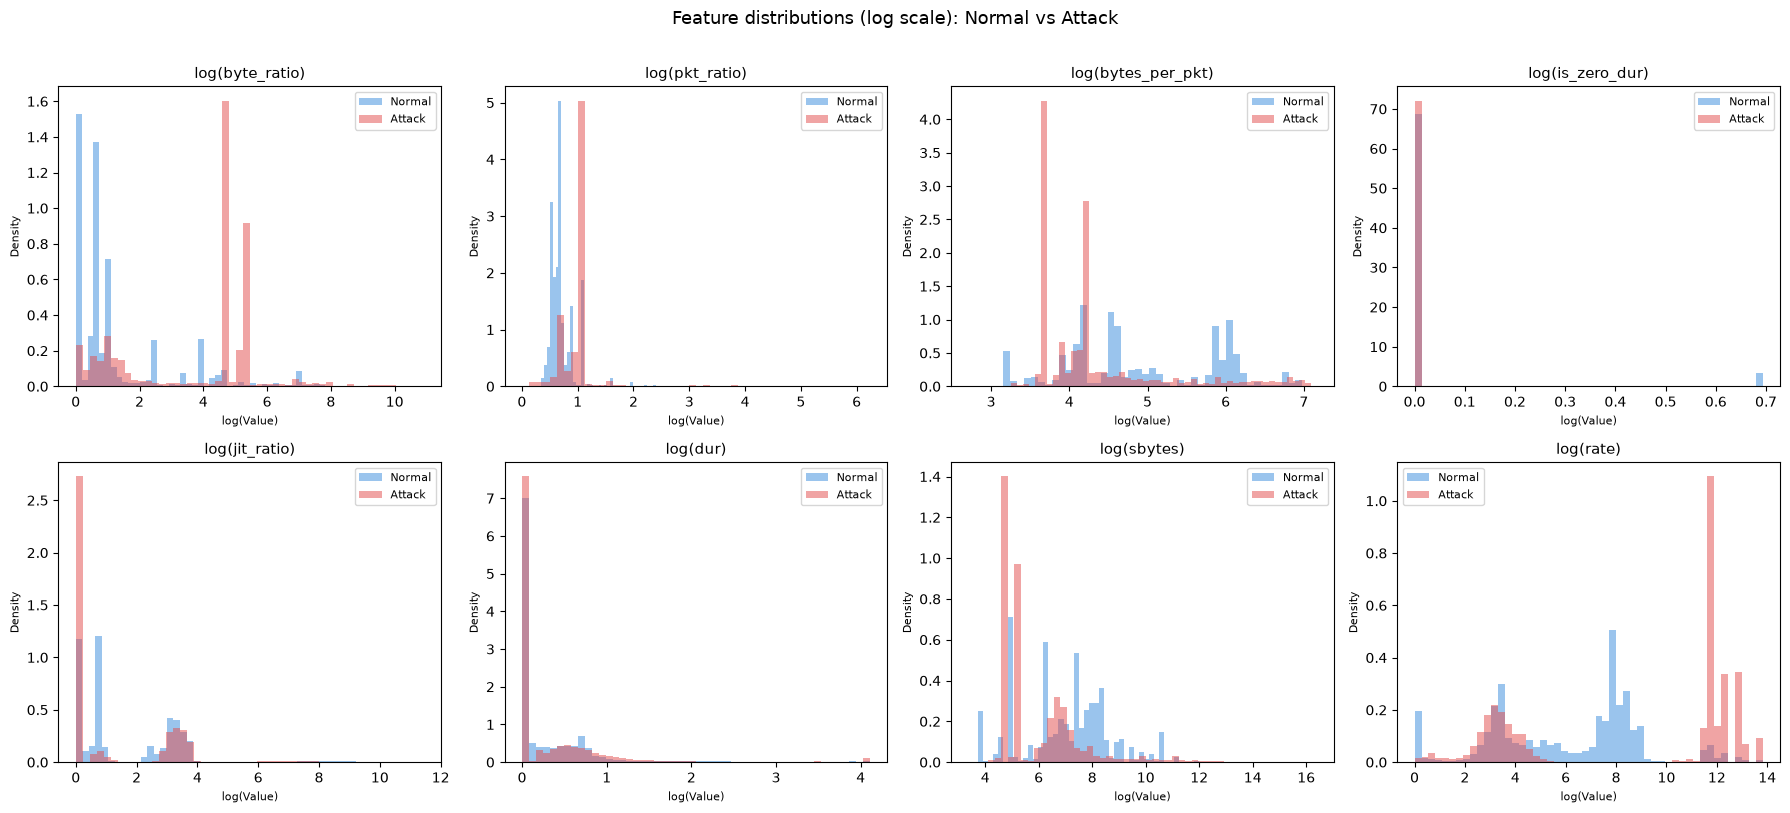

In [23]:
features_to_check = ['byte_ratio', 'pkt_ratio', 'bytes_per_pkt', 
                     'is_zero_dur', 'jit_ratio', 'dur', 'sbytes', 'rate']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, feat in zip(axes.flat, features_to_check):
    normal = np.log1p(df[df['label'] == 0][feat].clip(lower=0))
    attack = np.log1p(df[df['label'] == 1][feat].clip(lower=0))
    
    ax.hist(normal, bins=50, alpha=0.5, label='Normal', color='#378ADD', density=True)
    ax.hist(attack, bins=50, alpha=0.5, label='Attack',  color='#E24B4A', density=True)
    ax.set_title(f'log({feat})', fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlabel('log(Value)', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)

plt.suptitle('Feature distributions (log scale): Normal vs Attack', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../static/feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

Based on plots, is_zero_dur and jit_ratio are insignifcant and can be dropped

In [24]:
for frame in [df, df_test]:
    frame.drop(
        columns=['is_zero_dur', 'jit_ratio'],
        inplace=True,
        errors='ignore'
    )

In [25]:
inf_counts = df.replace([np.inf, -np.inf], np.nan).isnull().sum()
print("Columns with inf values:")
print(inf_counts[inf_counts > 0])

# Replace any infinities with 0
df = df.replace([np.inf, -np.inf], 0)
df_test = df_test.replace([np.inf, -np.inf], 0)
print("Cleaned.")

Columns with inf values:
Series([], dtype: int64)
Cleaned.


In [26]:
df.to_csv('../data/train_features.csv', index=False)
df_test.to_csv('../data/test_features.csv', index=False)

print(f"Saved train_features.csv — {df.shape}")
print(f"Saved test_features.csv  — {df_test.shape}")

Saved train_features.csv — (175341, 196)
Saved test_features.csv  — (82332, 196)
